# 01. Exploratory Data Analysis (EDA)

## Superstore Sales Data Mining Project

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append('..')

from src.data.loader import DataLoader
from src.data.cleaner import DataCleaner
from src.visualization.plots import plot_distribution, plot_correlation_matrix, plot_category_distribution

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Load Data

In [3]:
# Initialize loader
loader = DataLoader(data_path='../data/raw/')

# Generate sample data (or load from file)
df = loader.generate_sample_data(n_orders=2000)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

INFO:src.data.loader:Generated 4982 sample records


Dataset shape: (4982, 21)

First few rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,OD-000001,1620604800000000000,2021-05-16,Same Day,Customer-0382,Customer-0382,Corporate,United States,San Diego,Illinois,94162,South,PROD-4243,Office Supplies,Paper,Paper - Item 79,761.76,7,0.10,95.55
1,2,OD-000002,2011996800000000000,2033-10-10,Same Day,Customer-0532,Customer-0532,Consumer,United States,San Diego,Texas,98503,South,PROD-1006,Technology,Phones,Phones - Item 68,54.33,1,0.00,186.66
2,3,OD-000002,2011996800000000000,2033-10-07,Standard Class,Customer-0532,Customer-0532,Corporate,United States,Houston,California,12011,Central,PROD-6546,Technology,Phones,Phones - Item 95,793.80,1,0.00,119.28
3,4,OD-000003,1997827200000000000,2033-04-27,Second Class,Customer-0956,Customer-0956,Consumer,United States,San Antonio,Texas,15744,East,PROD-7980,Office Supplies,Supplies,Supplies - Item 30,37.26,3,0.10,-16.05
4,5,OD-000004,1994803200000000000,2033-03-25,First Class,Customer-0152,Customer-0152,Home Office,United States,Los Angeles,Illinois,36417,West,PROD-7268,Technology,Accessories,Accessories - Item 15,492.97,5,0.05,-20.97


## 2. Data Overview

In [4]:
# Inspect data
loader.inspect_data(verbose=True)


DATA INSPECTION SUMMARY

Shape: (4982, 21)

Columns: Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit

Duplicate rows: 0

Missing values:

Data types:
  - Row ID: int64
  - Order ID: object
  - Order Date: int64
  - Ship Date: datetime64[ns]
  - Ship Mode: object
  - Customer ID: object
  - Customer Name: object
  - Segment: object
  - Country: object
  - City: object
  - State: object
  - Postal Code: int64
  - Region: object
  - Product ID: object
  - Category: object
  - Sub-Category: object
  - Product Name: object
  - Sales: float64
  - Quantity: int64
  - Discount: float64
  - Profit: float64



{'shape': (4982, 21),
 'columns': ['Row ID',
  'Order ID',
  'Order Date',
  'Ship Date',
  'Ship Mode',
  'Customer ID',
  'Customer Name',
  'Segment',
  'Country',
  'City',
  'State',
  'Postal Code',
  'Region',
  'Product ID',
  'Category',
  'Sub-Category',
  'Product Name',
  'Sales',
  'Quantity',
  'Discount',
  'Profit'],
 'dtypes': {'Row ID': dtype('int64'),
  'Order ID': dtype('O'),
  'Order Date': dtype('int64'),
  'Ship Date': dtype('<M8[ns]'),
  'Ship Mode': dtype('O'),
  'Customer ID': dtype('O'),
  'Customer Name': dtype('O'),
  'Segment': dtype('O'),
  'Country': dtype('O'),
  'City': dtype('O'),
  'State': dtype('O'),
  'Postal Code': dtype('int64'),
  'Region': dtype('O'),
  'Product ID': dtype('O'),
  'Category': dtype('O'),
  'Sub-Category': dtype('O'),
  'Product Name': dtype('O'),
  'Sales': dtype('float64'),
  'Quantity': dtype('int64'),
  'Discount': dtype('float64'),
  'Profit': dtype('float64')},
 'head': {'Row ID': {0: 1, 1: 2, 2: 3, 3: 4, 4: 5},
  'Order 

In [5]:
# Column information
loader.get_column_info()

,Column,Data Type,Non-Null Count,Null Count,Unique Values,Sample Values
0,Row ID,int64,4982,0,4982,"[1, 2, 3]"
1,Order ID,object,4982,0,2000,"['OD-000001', 'OD-000002', 'OD-000002']"
2,Order Date,int64,4982,0,1701,"[1620604800000000000, 2011996800000000000, 201..."
3,Ship Date,datetime64[ns],4982,0,3021,"[Timestamp('2021-05-16 00:00:00'), Timestamp('..."
4,Ship Mode,object,4982,0,4,"[np.str_('Same Day'), np.str_('Same Day'), np...."
5,Customer ID,object,4982,0,849,"['Customer-0382', 'Customer-0532', 'Customer-0..."
6,Customer Name,object,4982,0,849,"['Customer-0382', 'Customer-0532', 'Customer-0..."
7,Segment,object,4982,0,3,"[np.str_('Corporate'), np.str_('Consumer'), np..."
8,Country,object,4982,0,1,"['United States', 'United States', 'United Sta..."
9,City,object,4982,0,8,"[np.str_('San Diego'), np.str_('San Diego'), n..."


## 3. Summary Statistics

In [6]:
# Numeric columns statistics
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,4982.000000,4.982000e+03,4982,4982.000000,4982.000000,4982.000000,4982.000000,4982.000000
mean,2491.500000,1.806114e+18,2027-03-30 13:59:22.424728832,54931.087515,503.756357,5.023685,0.100833,71.540395
min,1.000000,1.546387e+18,2019-01-05 00:00:00,10001.000000,10.050000,1.000000,0.000000,-49.950000
25%,1246.250000,1.680761e+18,2023-04-10 06:00:00,32173.750000,255.672500,3.000000,0.050000,8.632500
50%,2491.500000,1.807142e+18,2027-04-11 00:00:00,55180.500000,505.605000,5.000000,0.100000,68.460000
75%,3736.750000,1.934842e+18,2031-04-29 18:00:00,77801.500000,752.095000,7.000000,0.150000,133.185000
max,4982.000000,2.064614e+18,2035-06-10 00:00:00,99997.000000,999.870000,9.000000,0.200000,199.970000
std,1438.323851,1.487233e+17,NaN,26194.943764,285.039876,2.583254,0.071085,72.240459


In [7]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:")
for col in categorical_cols:
    print(f"\n{col} - {df[col].nunique()} unique values:")
    print(df[col].value_counts().head())

Categorical columns:

Order ID - 2000 unique values:
Order ID
OD-001994    4
OD-001993    4
OD-001991    4
OD-000005    4
OD-001983    4
Name: count, dtype: int64

Ship Mode - 4 unique values:
Ship Mode
First Class       1284
Second Class      1238
Same Day          1233
Standard Class    1227
Name: count, dtype: int64

Customer ID - 849 unique values:
Customer ID
Customer-0648    18
Customer-0554    18
Customer-0980    17
Customer-0915    17
Customer-0012    17
Name: count, dtype: int64

Customer Name - 849 unique values:
Customer Name
Customer-0648    18
Customer-0554    18
Customer-0980    17
Customer-0915    17
Customer-0012    17
Name: count, dtype: int64

Segment - 3 unique values:
Segment
Consumer       1680
Corporate      1671
Home Office    1631
Name: count, dtype: int64

Country - 1 unique values:
Country
United States    4982
Name: count, dtype: int64

City - 8 unique values:
City
San Diego      658
Chicago        627
Los Angeles    626
San Antonio    624
Houston        622


## 4. Missing Values & Duplicates

In [8]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]

if len(missing_df) > 0:
    print("Missing values:")
    print(missing_df)
else:
    print("No missing values found!")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

No missing values found!

Duplicate rows: 0


## 5. Distribution Analysis

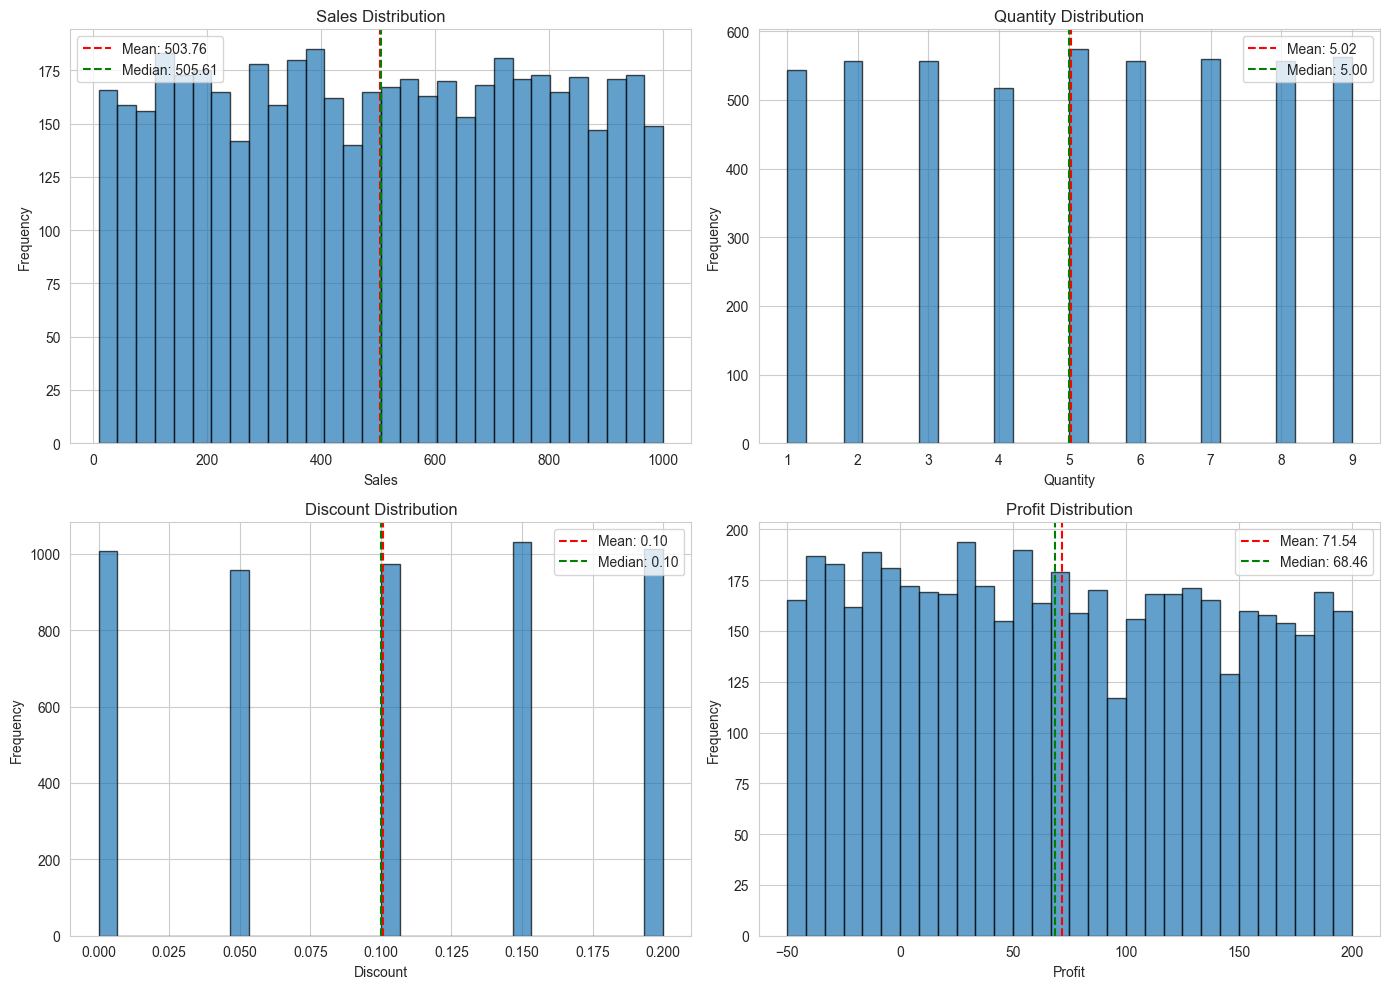

Saved: outputs/figures/01_distribution_numeric.png


In [9]:
# Plot distributions
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{col} Distribution')
    
    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_distribution_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/01_distribution_numeric.png")

## 6. Category Distribution

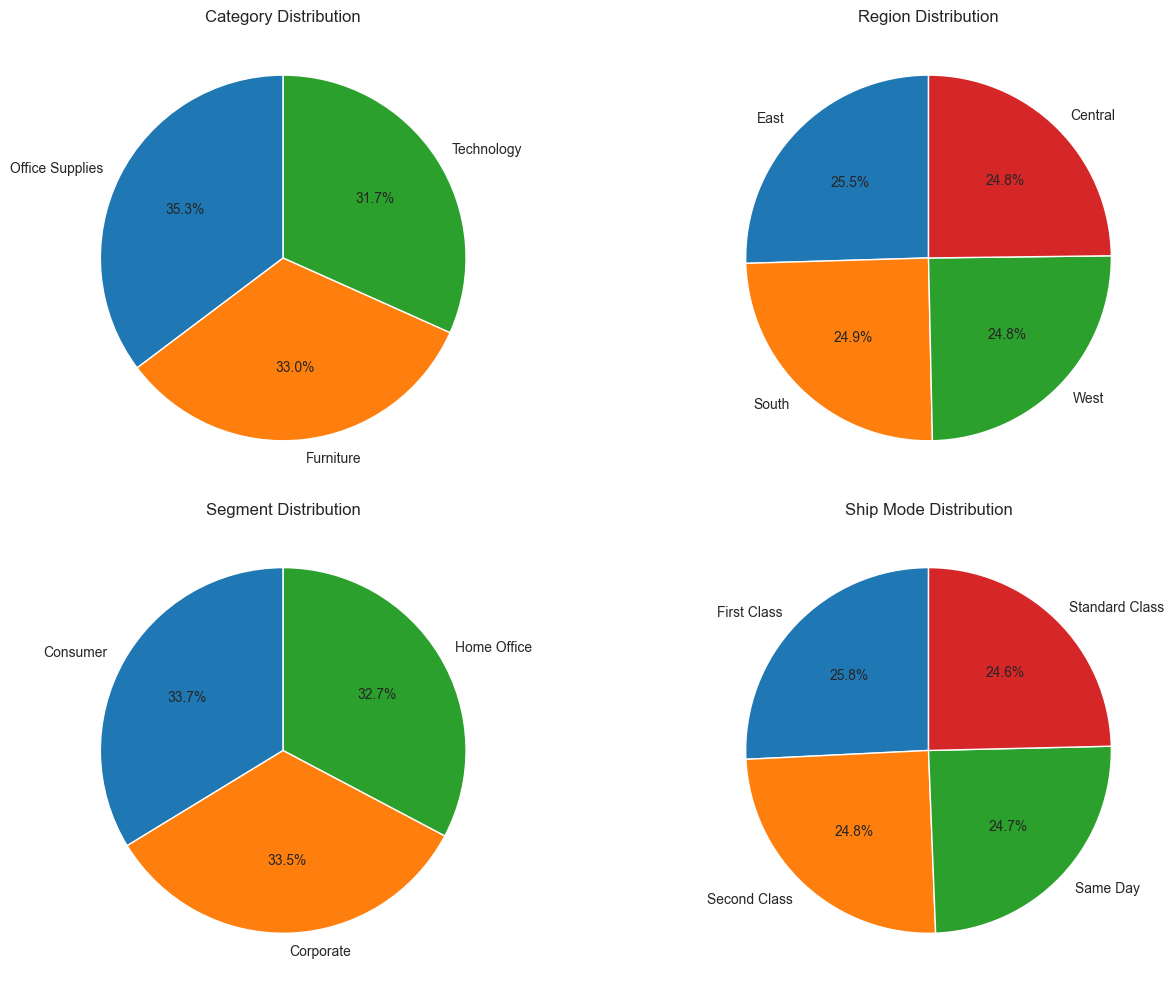

Saved: outputs/figures/02_distribution_category.png


In [10]:
# Plot category distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cat_cols = ['Category', 'Region', 'Segment', 'Ship Mode']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/02_distribution_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/02_distribution_category.png")

## 7. Correlation Analysis

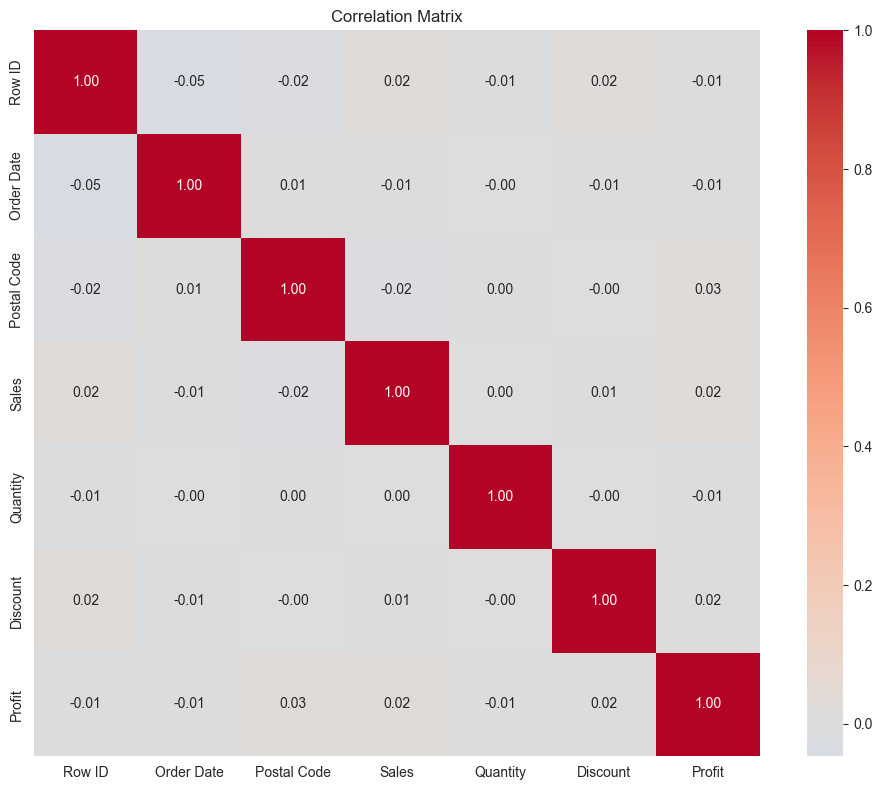

Saved: outputs/figures/03_correlation_matrix.png


In [11]:
# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/03_correlation_matrix.png")

## 8. Time Series Analysis

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


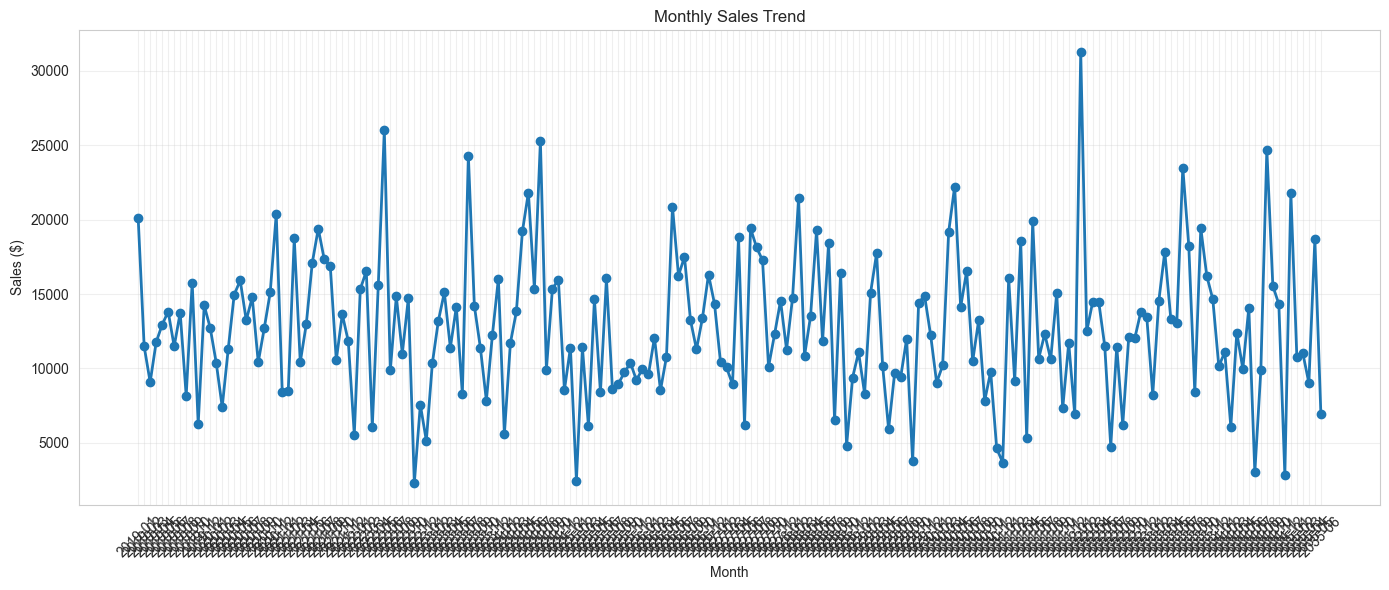

Saved: outputs/figures/04_monthly_sales.png


In [12]:
# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sales over time (monthly)
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/04_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/04_monthly_sales.png")

## 9. Sales by Category

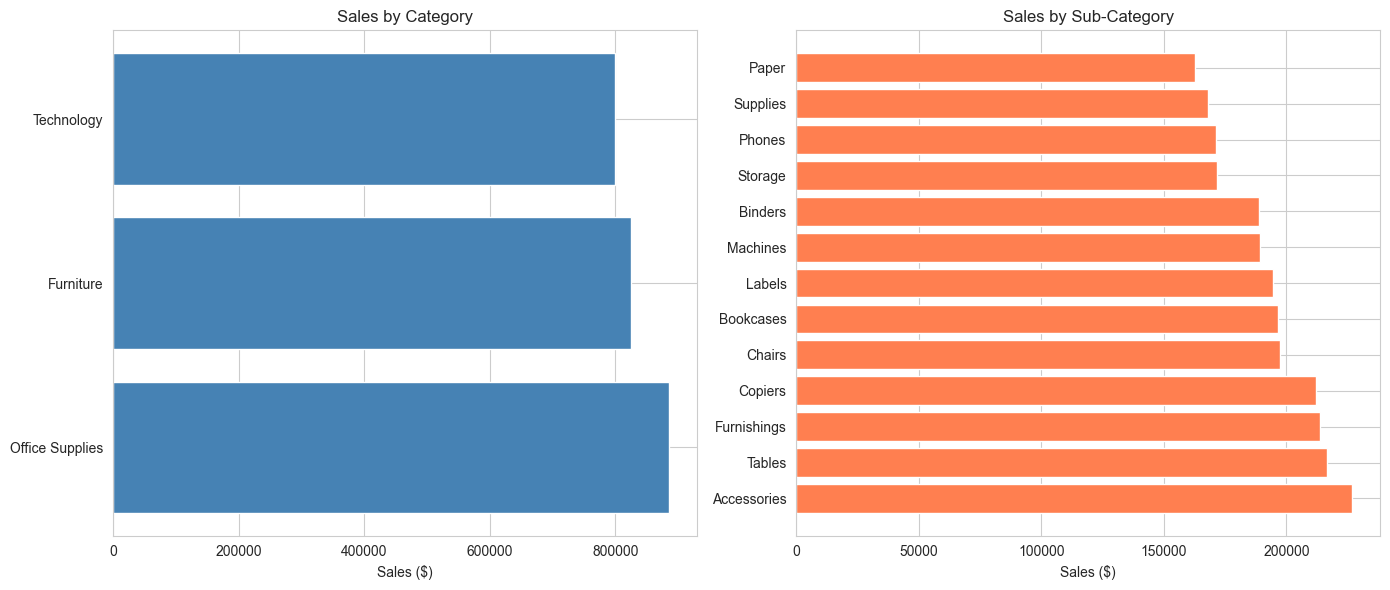

Saved: outputs/figures/05_sales_by_category.png


In [13]:
# Sales by Category and Sub-Category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# By Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].barh(cat_sales.index, cat_sales.values, color='steelblue')
axes[0].set_xlabel('Sales ($)')
axes[0].set_title('Sales by Category')

# By Sub-Category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
axes[1].barh(subcat_sales.index, subcat_sales.values, color='coral')
axes[1].set_xlabel('Sales ($)')
axes[1].set_title('Sales by Sub-Category')

plt.tight_layout()
plt.savefig('../outputs/figures/05_sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/05_sales_by_category.png")

## 10. Save Summary

In [14]:
# Save cleaned data for next step
df.to_csv('../data/processed/01_eda_data.csv', index=False)

# Summary statistics
summary_stats = loader.get_summary_stats()
print("Summary Statistics:")
for key, value in summary_stats.items():
    print(f"  {key}: {value}")

print("\nEDA completed!")
print("Saved: data/processed/01_eda_data.csv")

Summary Statistics:
  total_orders: 2000
  total_customers: 849
  total_sales: 2509714.17
  total_profit: 356414.25
  date_range: {'min': '2019-01-02 00:00:00', 'max': '2035-06-05 00:00:00'}

EDA completed!
Saved: data/processed/01_eda_data.csv
